# Chapter 56 — Queries, Keys, and Values in Plain English

## Learning goals

Chapter 54 used attention weights to average vectors, and Chapter 55 used dot products as raw matching scores.

This chapter combines those operations by giving matching and contribution separate vector representations.

By the end of this chapter, you should be able to:

- Describe the distinct roles of query, key, and value vectors.
- Project one input sequence into query, key, and value matrices.
- Explain why query and key dimensions must match while value dimension may differ.
- Compute one query-key score manually.
- Build and label the complete attention score table.
- Apply a Boolean causal mask and row-wise softmax.
- Use attention weights to mix value vectors.
- Print each value contribution to one attention output.
- Explain why keys select weights while values supply output content.
- Trace the shapes through one complete unscaled causal-attention step.

## The big idea

Each input position is transformed into three vectors with separate jobs:

- A **query** participates as the receiving position's side of a match.
- A **key** participates as each source position's side of a match.
- A **value** carries the source information mixed into the output.

The complete path is:

```text
query-key dot products
→ raw attention scores
→ causal mask
→ row-wise softmax
→ attention weights
→ weighted averages of value vectors
→ attention outputs
```

The query-key match determines the weight, but the corresponding value is what the weight multiplies.

## Terms used in this chapter

- An **input vector** is one position representation before the attention step.
- A **linear projection** multiplies an input by a parameter matrix to produce a new representation.
- A **query vector** is the receiving side of query-key matching.
- A **key vector** is the source side of query-key matching.
- A **value vector** is source information available for weighted mixing.
- An **attention score** is a raw query-key dot product.
- A **causal mask** marks future source positions as unavailable.
- An **attention weight** is a normalized coefficient over allowed source positions.
- An **attention output** is a weighted average of value vectors.
- A **score table** contains one row per query position and one column per key position.

## Plain-English roles are mnemonics

It is useful to remember a query as “what this position seeks,” a key as “what this position offers for matching,” and a value as “what this position contributes.”

These phrases describe computational roles rather than guaranteeing that individual learned vector components have human-readable meanings.

The matrices in this chapter are fixed for reproducibility, while a trained attention layer learns them with gradient descent.

## Create a tiny input sequence

Use three tokens with four-dimensional hand-written input vectors.

The batch dimension is omitted, so `[C, D_in]` stands in for the later `[B, C, D_in]` shape.

In [1]:
import torch

device = "cpu"
tokens = ["the", "dog", "barked"]
input_vectors = torch.tensor(
    [
        [1.0, 0.0, 0.0, 0.5],
        [0.0, 1.0, 0.0, 0.5],
        [0.0, 0.0, 1.0, 0.5],
    ],
    dtype=torch.float32,
    device=device,
)

print("device:", device)
print("input shape:", input_vectors.shape)
print()
print("position | token  | input vector")
print("-" * 51)
for position, token in enumerate(tokens):
    print(f"{position:>8} | {token:>6} | {input_vectors[position].tolist()}")

device: cpu
input shape: torch.Size([3, 4])

position | token  | input vector
---------------------------------------------------
       0 |    the | [1.0, 0.0, 0.0, 0.5]
       1 |    dog | [0.0, 1.0, 0.0, 0.5]
       2 | barked | [0.0, 0.0, 1.0, 0.5]


Every row remains a separate position representation with input dimension `D_in=4`.

## Define three shared projection matrices

Use query and key dimension `D_qk=2` so their rows can be dotted together.

Use value dimension `D_v=3` to make clear that values need not have the query-key dimension.

The right-multiplication convention here gives every projection shape `[D_in, D_output]`, and no bias is included in this simplified example.

In [2]:
query_projection = torch.tensor(
    [
        [1.0, 0.0],
        [0.0, 0.5],
        [0.0, 0.0],
        [0.5, 0.5],
    ],
    dtype=torch.float32,
    device=device,
)
key_projection = torch.tensor(
    [
        [1.0, 0.0],
        [0.0, 1.0],
        [0.0, 0.5],
        [0.5, 0.5],
    ],
    dtype=torch.float32,
    device=device,
)
value_projection = torch.tensor(
    [
        [0.5, 0.0, 0.0],
        [0.0, 1.0, 0.0],
        [1.0, 0.0, 0.5],
        [0.0, 0.5, 0.5],
    ],
    dtype=torch.float32,
    device=device,
)

print("query projection shape:", query_projection.shape)
print(query_projection)
print("key projection shape:", key_projection.shape)
print(key_projection)
print("value projection shape:", value_projection.shape)
print(value_projection)

query projection shape: torch.Size([4, 2])
tensor([[1.0000, 0.0000],
        [0.0000, 0.5000],
        [0.0000, 0.0000],
        [0.5000, 0.5000]])
key projection shape: torch.Size([4, 2])
tensor([[1.0000, 0.0000],
        [0.0000, 1.0000],
        [0.0000, 0.5000],
        [0.5000, 0.5000]])
value projection shape: torch.Size([4, 3])
tensor([[0.5000, 0.0000, 0.0000],
        [0.0000, 1.0000, 0.0000],
        [1.0000, 0.0000, 0.5000],
        [0.0000, 0.5000, 0.5000]])


The same three matrices are applied at every position, so the projections share parameters across the sequence.

## Project inputs into queries, keys, and values

Apply each matrix to all three input rows with matrix multiplication.

In [3]:
query_vectors = input_vectors @ query_projection
key_vectors = input_vectors @ key_projection
value_vectors = input_vectors @ value_projection

print("query shape:", query_vectors.shape)
print("key shape:", key_vectors.shape)
print("value shape:", value_vectors.shape)
print()
print("position | token  | query        | key          | value")
print("-" * 79)
for position, token in enumerate(tokens):
    query = [round(value, 3) for value in query_vectors[position].tolist()]
    key = [round(value, 3) for value in key_vectors[position].tolist()]
    value = [round(item, 3) for item in value_vectors[position].tolist()]
    print(f"{position:>8} | {token:>6} | {str(query):>12} | {str(key):>12} | {value}")

query shape: torch.Size([3, 2])
key shape: torch.Size([3, 2])
value shape: torch.Size([3, 3])

position | token  | query        | key          | value
-------------------------------------------------------------------------------
       0 |    the | [1.25, 0.25] | [1.25, 0.25] | [0.5, 0.25, 0.25]
       1 |    dog | [0.25, 0.75] | [0.25, 1.25] | [0.0, 1.25, 0.25]
       2 | barked | [0.25, 0.25] | [0.25, 0.75] | [1.0, 0.25, 0.75]


Queries and keys have shape `[3, 2]`, which makes every query-key dot product valid.

Values have shape `[3, 3]`, and that final dimension will become the attention output dimension.

## Compute one query-key score manually

Compare the `barked` query at receiving position 2 with the `dog` key at source position 1.

In [4]:
barked_query = query_vectors[2]
dog_key = key_vectors[1]
manual_score = 0.0

print("component | query | key   | product")
print("-" * 39)
for component in range(barked_query.shape[0]):
    query_component = barked_query[component].item()
    key_component = dog_key[component].item()
    product = query_component * key_component
    manual_score += product
    print(
        f"{component:>9} | "
        f"{query_component:>5.3f} | "
        f"{key_component:>5.3f} | "
        f"{product:>7.4f}"
    )

torch_score = torch.dot(barked_query, dog_key).item()
print("-" * 39)
print("manual score:", manual_score)
print("torch.dot score:", torch_score)
print("scores match:", manual_score == torch_score)

component | query | key   | product
---------------------------------------
        0 | 0.250 | 0.250 |  0.0625
        1 | 0.250 | 1.250 |  0.3125
---------------------------------------
manual score: 0.375
torch.dot score: 0.375
scores match: True


The score is `0.375`, and it is still an unnormalized real number rather than an attention weight.

## Build the full score table

Multiply `[C, D_qk]` queries by transposed `[D_qk, C]` keys.

Rows represent receiving query positions, and columns represent source key positions.

In [5]:
attention_scores = query_vectors @ key_vectors.T

header = "query \ key".rjust(12)
for token in tokens:
    header += f" | {token:>8}"

print("score shape:", attention_scores.shape)
print(header)
print("-" * len(header))
for query_position, query_token in enumerate(tokens):
    row_text = f"{query_token:>12}"
    for key_position in range(len(tokens)):
        score = attention_scores[query_position, key_position].item()
        row_text += f" | {score:>8.3f}"
    print(row_text)

score shape: torch.Size([3, 3])
 query \ key |      the |      dog |   barked
---------------------------------------------
         the |    1.625 |    0.625 |    0.500
         dog |    0.500 |    1.000 |    0.625
      barked |    0.375 |    0.375 |    0.250


Entry `[i, j]` is the dot product between query row `i` and key row `j`.

The table contains raw, unscaled matching scores, including scores for future positions that must be blocked next.

## Apply a Boolean causal mask

A receiving position may use itself and earlier source positions but not later source positions.

Replace disallowed scores with negative infinity before softmax.

In [6]:
number_of_positions = input_vectors.shape[0]
causal_mask = torch.tril(
    torch.ones(
        number_of_positions,
        number_of_positions,
        dtype=torch.bool,
        device=device,
    )
)
masked_attention_scores = attention_scores.masked_fill(
    ~causal_mask,
    float("-inf"),
)

print("causal mask:")
print(causal_mask)
print("masked attention scores:")
print(masked_attention_scores)

causal mask:
tensor([[ True, False, False],
        [ True,  True, False],
        [ True,  True,  True]])
masked attention scores:
tensor([[1.6250,   -inf,   -inf],
        [0.5000, 1.0000,   -inf],
        [0.3750, 0.3750, 0.2500]])


Negative infinity makes each masked entry exactly zero after softmax.

Every row has at least one allowed position, so this example never applies softmax to a fully masked row.

## Convert scores into attention weights

Apply softmax across source columns so each receiving row becomes a normalized distribution over its allowed positions.

In [7]:
attention_weights = torch.softmax(masked_attention_scores, dim=1)

header = "receiver \ source".rjust(18)
for token in tokens:
    header += f" | {token:>8}"

print("weight shape:", attention_weights.shape)
print(header)
print("-" * len(header))
for receiving_position, receiving_token in enumerate(tokens):
    row_text = f"{receiving_token:>18}"
    for source_position in range(len(tokens)):
        weight = attention_weights[receiving_position, source_position].item()
        row_text += f" | {weight:>8.3f}"
    print(row_text)

print("row sums:", attention_weights.sum(dim=1))
print("future weights are zero:", bool(torch.all(attention_weights[~causal_mask] == 0)))

weight shape: torch.Size([3, 3])
 receiver \ source |      the |      dog |   barked
---------------------------------------------------
               the |    1.000 |    0.000 |    0.000
               dog |    0.378 |    0.622 |    0.000
            barked |    0.347 |    0.347 |    0.306
row sums: tensor([1., 1., 1.])
future weights are zero: True


The weights are a mathematical distribution over source positions, not a vocabulary distribution over possible next tokens.

The current chapter intentionally omits score scaling so the next chapter can introduce its purpose and formula directly.

## Mix value vectors into attention outputs

Multiply `[C, C]` weights by `[C, D_v]` values to retain one `D_v`-dimensional output per receiving position.

In [8]:
attention_outputs = attention_weights @ value_vectors

print("output shape:", attention_outputs.shape)
print("position | token  | attention output")
print("-" * 55)
for position, token in enumerate(tokens):
    rounded_output = [round(value, 4) for value in attention_outputs[position].tolist()]
    print(f"{position:>8} | {token:>6} | {rounded_output}")

output shape: torch.Size([3, 3])
position | token  | attention output
-------------------------------------------------------
       0 |    the | [0.5, 0.25, 0.25]
       1 |    dog | [0.1888, 0.8725, 0.25]
       2 | barked | [0.4796, 0.5969, 0.4031]


The output shape `[3, 3]` follows the value dimension rather than the query-key dimension.

Queries and keys determined the `[3, 3]` weights, while values determined the content and final width of the outputs.

## Print contributions to the final output

Expand the `barked` row as one attention weight times each source value vector.

In [9]:
barked_weights = attention_weights[2]
weighted_value_contributions = barked_weights.unsqueeze(1) * value_vectors

print("source | weight | value             | weighted contribution")
print("-" * 70)
for source_position, source_token in enumerate(tokens):
    value = [
        round(component, 4) for component in value_vectors[source_position].tolist()
    ]
    contribution = [
        round(component, 4)
        for component in weighted_value_contributions[source_position].tolist()
    ]
    print(
        f"{source_token:>6} | "
        f"{barked_weights[source_position].item():>6.3f} | "
        f"{str(value):>17} | "
        f"{contribution}"
    )

contribution_sum = weighted_value_contributions.sum(dim=0)
print("sum of contributions:", contribution_sum)
print("stored barked output:", attention_outputs[2])
print("outputs match:", torch.allclose(contribution_sum, attention_outputs[2]))

source | weight | value             | weighted contribution
----------------------------------------------------------------------
   the |  0.347 | [0.5, 0.25, 0.25] | [0.1735, 0.0867, 0.0867]
   dog |  0.347 | [0.0, 1.25, 0.25] | [0.0, 0.4337, 0.0867]
barked |  0.306 | [1.0, 0.25, 0.75] | [0.3062, 0.0765, 0.2296]
sum of contributions: tensor([0.4796, 0.5969, 0.4031])
stored barked output: tensor([0.4796, 0.5969, 0.4031])
outputs match: True


The three source values are multiplied by weights created entirely from query-key matches.

Their sum equals the stored `barked` attention output.

## Change values without changing weights

Modify only the `dog` value vector while leaving every query and key untouched.

The score table and attention weights therefore remain fixed, but the mixed outputs change.

In [10]:
modified_value_vectors = value_vectors.clone()
modified_value_vectors[1] += torch.tensor(
    [2.0, -1.0, 0.5],
    dtype=torch.float32,
    device=device,
)
modified_outputs = attention_weights @ modified_value_vectors

print("original dog value:", value_vectors[1])
print("modified dog value:", modified_value_vectors[1])
print("barked attention weights:", attention_weights[2])
print("original barked output:", attention_outputs[2])
print("modified barked output:", modified_outputs[2])
print(
    "output changed:",
    not torch.allclose(
        attention_outputs[2],
        modified_outputs[2],
    ),
)

original dog value: tensor([0.0000, 1.2500, 0.2500])
modified dog value: tensor([2.0000, 0.2500, 0.7500])
barked attention weights: tensor([0.3469, 0.3469, 0.3062])
original barked output: tensor([0.4796, 0.5969, 0.4031])
modified barked output: tensor([1.1735, 0.2500, 0.5765])
output changed: True


This experiment isolates the central gotcha: query-key matches choose coefficients, while values determine what those coefficients carry into the result.

A trained model can learn separate projections for those two jobs.

## Visualize the causal attention weights

Plot the normalized table as one annotated heatmap with receiving positions on rows and source positions on columns.

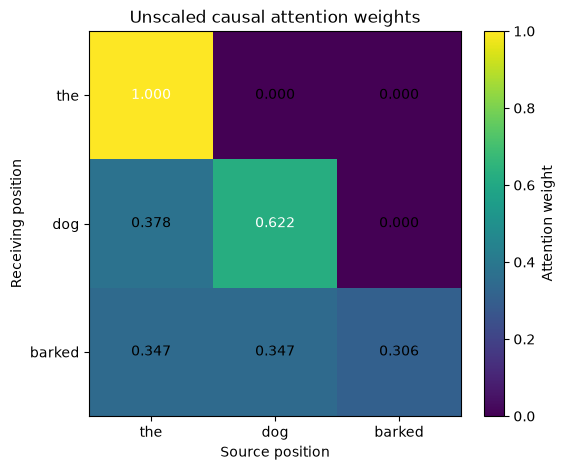

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.imshow(attention_weights, aspect="auto", vmin=0.0, vmax=1.0)
plt.colorbar(label="Attention weight")
plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Source position")
plt.ylabel("Receiving position")
plt.title("Unscaled causal attention weights")

for row in range(len(tokens)):
    for column in range(len(tokens)):
        plt.text(
            column,
            row,
            f"{attention_weights[row, column].item():.3f}",
            ha="center",
            va="center",
            color="white" if attention_weights[row, column] > 0.5 else "black",
        )

plt.show()

The zero upper triangle shows that future source positions make no contribution in causal left-to-right attention.

## Package the unscaled attention step

Validate ranks, input widths, query-key compatibility, devices, and floating-point dtypes before repeating the computation.

In [12]:
def compute_unscaled_causal_attention(
    input_vectors: torch.Tensor,
    query_projection: torch.Tensor,
    key_projection: torch.Tensor,
    value_projection: torch.Tensor,
) -> dict[str, torch.Tensor]:
    projections = [query_projection, key_projection, value_projection]
    if input_vectors.ndim != 2:
        raise ValueError("input_vectors must have shape [positions, input dimension].")
    if any(projection.ndim != 2 for projection in projections):
        raise ValueError("Every projection must be a two-dimensional matrix.")
    if any(projection.shape[0] != input_vectors.shape[1] for projection in projections):
        raise ValueError("Every projection input width must match input_vectors.")
    if query_projection.shape[1] != key_projection.shape[1]:
        raise ValueError("Query and key output dimensions must match.")
    if any(projection.device != input_vectors.device for projection in projections):
        raise ValueError("Inputs and projections must use the same device.")
    if not torch.is_floating_point(input_vectors) or any(
        not torch.is_floating_point(projection) for projection in projections
    ):
        raise ValueError("Inputs and projections must be floating-point tensors.")

    queries = input_vectors @ query_projection
    keys = input_vectors @ key_projection
    values = input_vectors @ value_projection
    scores = queries @ keys.T
    positions = input_vectors.shape[0]
    mask = torch.tril(
        torch.ones(positions, positions, dtype=torch.bool, device=input_vectors.device)
    )
    masked_scores = scores.masked_fill(~mask, float("-inf"))
    weights = torch.softmax(masked_scores, dim=1)
    outputs = weights @ values

    return {
        "queries": queries,
        "keys": keys,
        "values": values,
        "scores": scores,
        "mask": mask,
        "masked_scores": masked_scores,
        "weights": weights,
        "outputs": outputs,
    }


attention_result = compute_unscaled_causal_attention(
    input_vectors,
    query_projection,
    key_projection,
    value_projection,
)

print(
    "helper scores match:",
    torch.allclose(attention_result["scores"], attention_scores),
)
print(
    "helper weights match:",
    torch.allclose(attention_result["weights"], attention_weights),
)
print(
    "helper outputs match:",
    torch.allclose(attention_result["outputs"], attention_outputs),
)

helper scores match: True
helper weights match: True
helper outputs match: True


The helper reproduces every earlier score, weight, and output while keeping the roles available for inspection.

## Shape summary

For `C` positions, input dimension `D_in`, shared query-key dimension `D_qk`, and value dimension `D_v`:

```text
inputs:             [C, D_in]
query projection:   [D_in, D_qk]
key projection:     [D_in, D_qk]
value projection:   [D_in, D_v]
queries:            [C, D_qk]
keys:               [C, D_qk]
values:             [C, D_v]
scores and weights: [C, C]
outputs:            [C, D_v]
```

A later batched implementation adds a leading `B` dimension to position-dependent tensors.

## Common mistakes

- Do not confuse the mnemonic meanings of learned vectors with guaranteed interpretations.
- Do not use different query and key widths because their dot products require matching dimensions.
- Do not require value width to equal query-key width.
- Do not describe raw query-key scores as probabilities.
- Do not allow future scores through the causal mask.
- Do not apply softmax across the receiving-position dimension.
- Do not mix key vectors into the output when the values are the intended content.
- Do not forget that this chapter intentionally omits attention-score scaling.

## Takeaways

Queries and keys participate in matching, while values participate in output mixing.

The core unscaled causal-attention computation is:

```text
Q = XWq
K = XWk
V = XWv
scores = QKᵀ
weights = softmax(causal_mask(scores))
outputs = weights V
```

Query and key dimensions must match, but the output width follows the value dimension.

The query-key match decides each coefficient, and the corresponding value supplies the information multiplied by that coefficient.

## What comes next

The next chapter scales query-key scores before masking and softmax.

Dividing by a factor based on query-key dimension helps prevent growing dot-product magnitude from making attention distributions unnecessarily sharp.